<a href="https://colab.research.google.com/github/GabrielDSAlves/Imputacao-de-dados-usando-MLP/blob/main/mlpimputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nesse notebook será realizado o experimento de imputação artificial


##Experimento 1 - Imputação de dados com MLP


---


#Importação das bibliotecas

Nesta etapa carregamos as bibliotecas que serão utilizadas para análise exploratória, visualização e manipulação dos dados.

In [ ]:
!pip install optuna -q

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Optuna
import optuna

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cpu


# Leitura do dataset

In [ ]:
caminho_dataset = "dataset_mp25_hospital_vital_brazil_2025.csv"

df = pd.read_csv(caminho_dataset)

print(df.shape)
df.head()

(8244, 5)


,nu_concentracao,mes,dia,hora,dia_semana
0,38.0,1,1,0,2
1,34.0,1,1,1,2
2,35.0,1,1,2,2
3,25.0,1,1,3,2
4,21.0,1,1,4,2


# Removendo valores extremos

In [ ]:
# Remover valores acima de um limite considerado incompatível com a escala esperada
limite_superior = 500

df = df[
    (df["nu_concentracao"] >= 0) &
    (df["nu_concentracao"] <= limite_superior)
].copy()

df = df.reset_index(drop=True)

print(df["nu_concentracao"].describe())

count    8104.000000
mean       12.089832
std         9.627241
min         0.000000
25%         7.000000
50%        11.000000
75%        15.000000
max       315.000000
Name: nu_concentracao, dtype: float64


# Criando lags

In [ ]:
# Garantir ordenação temporal
if "dh_medicao" in df.columns:
    df["dh_medicao"] = pd.to_datetime(df["dh_medicao"])
    df = df.sort_values("dh_medicao").reset_index(drop=True)

# Criar lags da concentração
df["lag_1"] = df["nu_concentracao"].shift(1)
df["lag_2"] = df["nu_concentracao"].shift(2)
df["lag_3"] = df["nu_concentracao"].shift(3)
df["lag_24"] = df["nu_concentracao"].shift(24)
df["lag_48"] = df["nu_concentracao"].shift(48)

# Criar médias móveis usando apenas valores anteriores
df["media_3"] = df["nu_concentracao"].shift(1).rolling(3).mean()
df["media_6"] = df["nu_concentracao"].shift(1).rolling(6).mean()
df["media_12"] = df["nu_concentracao"].shift(1).rolling(12).mean()

# Remover linhas iniciais sem histórico suficiente
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.head()

(8056, 13)


,nu_concentracao,mes,dia,hora,dia_semana,lag_1,lag_2,lag_3,lag_24,lag_48,media_3,media_6,media_12
0,14.0,1,11,2,5,6.0,9.0,14.0,15.0,38.0,9.666667,16.500000,15.083333
1,16.0,1,11,3,5,14.0,6.0,9.0,13.0,34.0,9.666667,15.333333,15.166667
2,12.0,1,11,4,5,16.0,14.0,6.0,13.0,35.0,12.000000,13.166667,15.083333
3,6.0,1,11,5,5,12.0,16.0,14.0,8.0,25.0,14.000000,11.833333,15.250000
4,4.0,1,11,6,5,6.0,12.0,16.0,7.0,21.0,11.333333,10.500000,14.666667


# Verificação inicial

Vamos garantir que o dataset está completo antes de remover valores artificialmente.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8056 entries, 0 to 8055
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   nu_concentracao  8056 non-null   float64
 1   mes              8056 non-null   int64  
 2   dia              8056 non-null   int64  
 3   hora             8056 non-null   int64  
 4   dia_semana       8056 non-null   int64  
 5   lag_1            8056 non-null   float64
 6   lag_2            8056 non-null   float64
 7   lag_3            8056 non-null   float64
 8   lag_24           8056 non-null   float64
 9   lag_48           8056 non-null   float64
 10  media_3          8056 non-null   float64
 11  media_6          8056 non-null   float64
 12  media_12         8056 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 818.3 KB


In [ ]:
df.isnull().sum()

,0
nu_concentracao,0
mes,0
dia,0
hora,0
dia_semana,0
lag_1,0
lag_2,0
lag_3,0
lag_24,0
lag_48,0


# Criação do eixo temporal


In [ ]:
# Verifica se existe coluna de data
if "dh_medicao" in df.columns:
    df["dh_medicao"] = pd.to_datetime(df["dh_medicao"])
    eixo_tempo = df["dh_medicao"]
else:
    eixo_tempo = np.arange(len(df))

print("Eixo temporal criado.")

Eixo temporal criado.


# Separação entre variável alvo e atributos

A variável que será artificialmente removida e depois imputada será:

`nu_concentracao`

As demais colunas numéricas serão usadas como atributos de entrada da MLP.

In [ ]:
target = "nu_concentracao"

features = [
    "mes",
    "dia",
    "hora",
    "dia_semana",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "media_3",
    "media_6",
    "media_12"
]

print("Variável alvo:", target)
print("Atributos usados:")
print(features)

Variável alvo: nu_concentracao
Atributos usados:
['mes', 'dia', 'hora', 'dia_semana', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'media_3', 'media_6', 'media_12']


# Remoção artificial de 20% dos valores

Agora vamos esconder artificialmente 20% dos valores de `nu_concentracao`.

Esses valores serão usados depois para avaliar a qualidade da imputação.

In [ ]:
# Copiar dataset original
df_experimento = df.copy()

# Percentual de valores que serão removidos
percentual_remocao = 0.20

# Quantidade de valores a remover
n_remover = int(len(df_experimento) * percentual_remocao)

# Selecionar índices aleatórios para remoção
indices_removidos = np.random.choice(
    df_experimento.index,
    size=n_remover,
    replace=False
)

# Guardar os valores reais antes de remover
valores_reais_removidos = df_experimento.loc[indices_removidos, target].copy()

# Criar coluna com valores ausentes artificiais
df_experimento["nu_concentracao_com_missing"] = df_experimento[target]

# Remover artificialmente os valores
df_experimento.loc[indices_removidos, "nu_concentracao_com_missing"] = np.nan

print("Total de registros:", len(df_experimento))
print("Valores removidos artificialmente:", len(indices_removidos))
print("Percentual removido:", df_experimento["nu_concentracao_com_missing"].isna().mean() * 100)

Total de registros: 8056
Valores removidos artificialmente: 1611
Percentual removido: 19.99751737835154


# Visualização dos valores removidos artificialmente


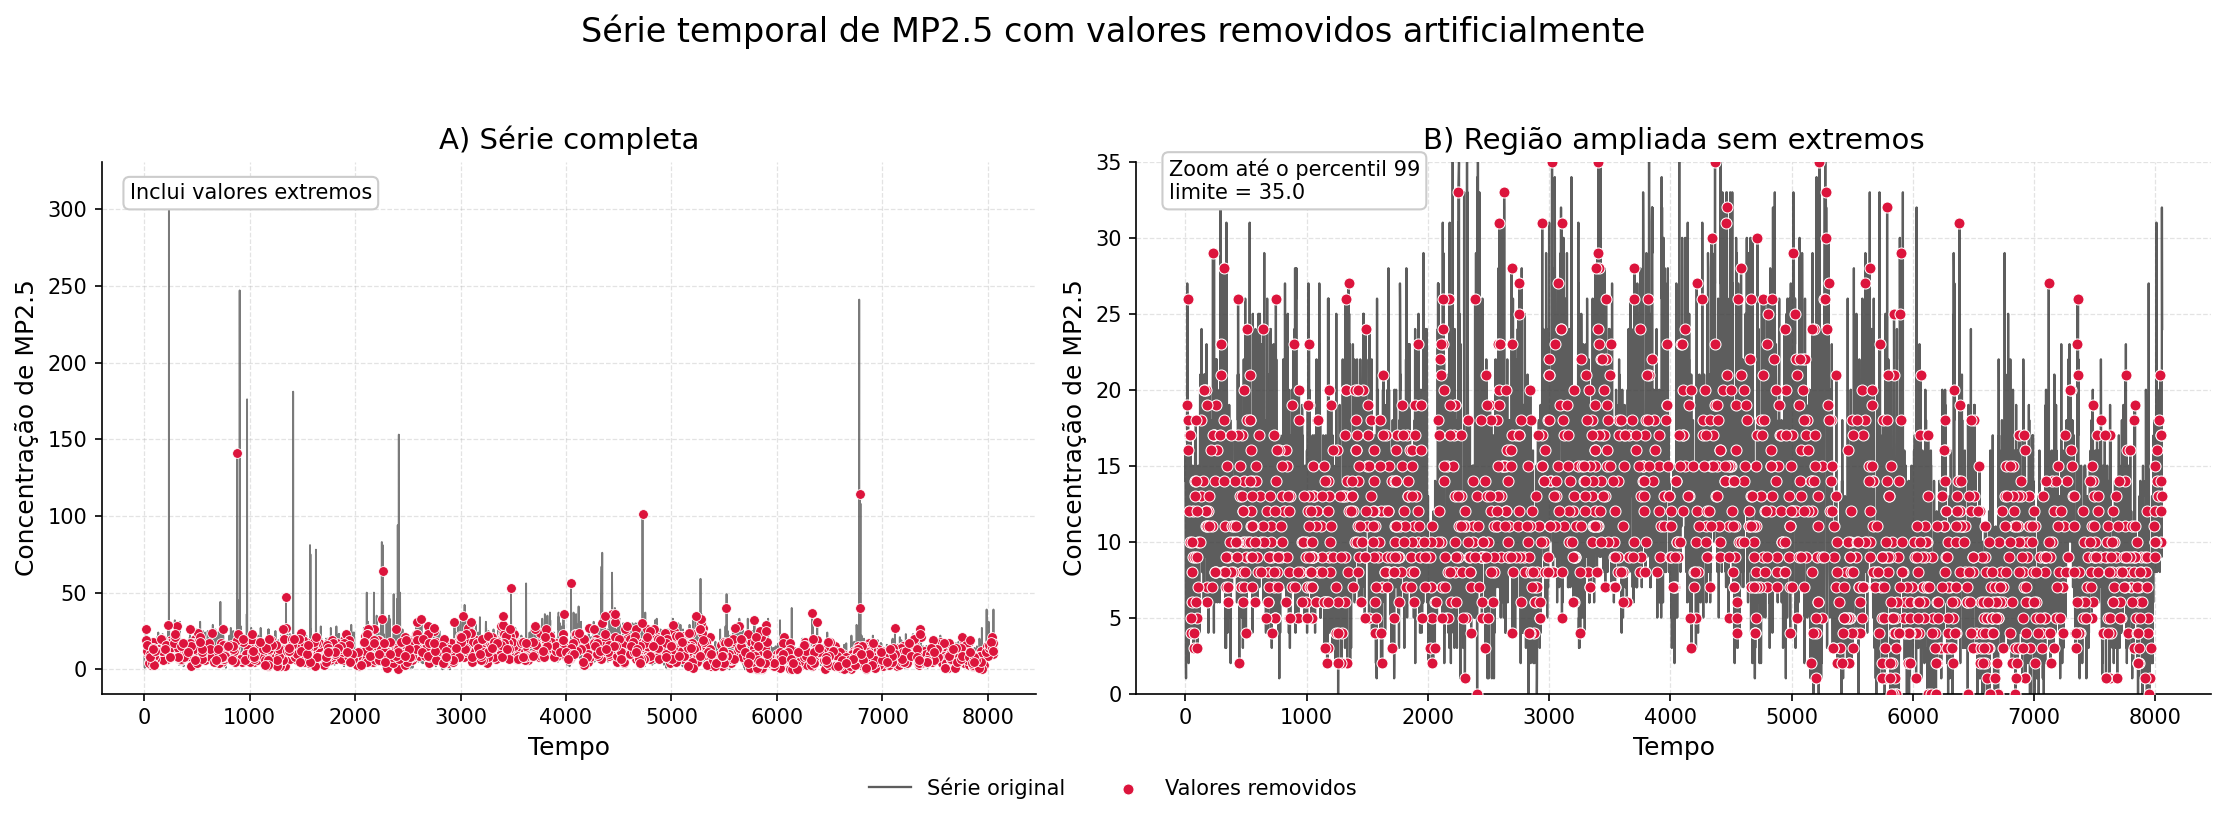

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

x = np.asarray(eixo_tempo)
y = df_experimento[target].to_numpy()

x_rem = x[indices_removidos]
y_rem = np.asarray(valores_reais_removidos)

# Corte dos extremos para o gráfico ampliado
limite_zoom = np.nanpercentile(y, 99)

mask_zoom = y <= limite_zoom
mask_rem_zoom = y_rem <= limite_zoom

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [1, 1.15]},
    sharex=True
)

ax_full, ax_zoom = axes

# =========================
# Subplot 1: série completa
# =========================
ax_full.plot(
    x, y,
    color="0.35",
    lw=0.9,
    alpha=0.8,
    label="Série original"
)

ax_full.scatter(
    x_rem, y_rem,
    color="crimson",
    s=22,
    edgecolor="white",
    linewidth=0.4,
    zorder=3,
    label="Valores removidos"
)

ax_full.set_title("A) Série completa")
ax_full.set_xlabel("Tempo")
ax_full.set_ylabel("Concentração de MP2.5")
ax_full.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

ax_full.text(
    0.03, 0.93,
    "Inclui valores extremos",
    transform=ax_full.transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.8")
)

# =========================
# Subplot 2: zoom sem extremos
# =========================
ax_zoom.plot(
    x[mask_zoom],
    y[mask_zoom],
    color="0.25",
    lw=1.1,
    alpha=0.85,
    label="Série original"
)

ax_zoom.scatter(
    x_rem[mask_rem_zoom],
    y_rem[mask_rem_zoom],
    color="crimson",
    s=28,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
    label="Valores removidos"
)

ax_zoom.set_ylim(0, limite_zoom)

ax_zoom.set_title("B) Região ampliada sem extremos")
ax_zoom.set_xlabel("Tempo")
ax_zoom.set_ylabel("Concentração de MP2.5")
ax_zoom.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

ax_zoom.text(
    0.03, 0.93,
    f"Zoom até o percentil 99\nlimite = {limite_zoom:.1f}",
    transform=ax_zoom.transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.8")
)

# Legenda única
handles, labels = ax_zoom.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.04)
)

fig.suptitle(
    "Série temporal de MP2.5 com valores removidos artificialmente",
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

# 7. Preparação dos dados para treinamento

A MLP será treinada apenas com os registros em que `nu_concentracao_com_missing` não está ausente.

Depois, ela será usada para prever os valores removidos.

In [ ]:
# Dados observados, ou seja, sem os valores removidos
df_observado = df_experimento.dropna(subset=["nu_concentracao_com_missing"]).copy()

# X e y para treinamento
X = df_observado[features].values
y = df_observado["nu_concentracao_com_missing"].values.reshape(-1, 1)

print("X:", X.shape)
print("y:", y.shape)

X: (6445, 12)
y: (6445, 1)


# Definição da MLP

In [ ]:
class MLPImputador(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()

        camadas = []

        # Primeira camada
        camadas.append(nn.Linear(input_dim, hidden_dim))
        camadas.append(nn.ReLU())

        # Camadas ocultas adicionais
        for _ in range(num_layers - 1):
            camadas.append(nn.Linear(hidden_dim, hidden_dim))
            camadas.append(nn.ReLU())

        # Saída com 1 neurônio para regressão
        camadas.append(nn.Linear(hidden_dim, 1))

        self.modelo = nn.Sequential(*camadas)

    def forward(self, x):
        return self.modelo(x)

# Função de treinamento


In [ ]:
def treinar_modelo(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    max_epochs=200,
    patience=20
):
    train_losses = []
    val_losses = []

    melhor_val_loss = np.inf
    contador = 0
    melhor_estado = None

    for epoch in range(max_epochs):
        # Treinamento
        model.train()
        perdas_treino = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            perdas_treino.append(loss.item())

        train_loss = np.mean(perdas_treino)

        # Validação
        model.eval()
        perdas_val = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                pred = model(xb)
                loss = criterion(pred, yb)

                perdas_val.append(loss.item())

        val_loss = np.mean(perdas_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Early Stopping
        if val_loss < melhor_val_loss:
            melhor_val_loss = val_loss
            melhor_estado = model.state_dict()
            contador = 0
        else:
            contador += 1

        if contador >= patience:
            break

    # Restaurar melhor modelo
    model.load_state_dict(melhor_estado)

    return model, train_losses, val_losses, melhor_val_loss

# Função auxiliar para DataLoader

Essa função transforma arrays NumPy em objetos compatíveis com PyTorch.

In [ ]:
def criar_loader(X, y, batch_size, shuffle=False):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)

    dataset = TensorDataset(X_tensor, y_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )

# Otimização com Optuna e TimeSeriesSplit

Agora vamos usar `TimeSeriesSplit` com 5 folds.


In [ ]:
def objective(trial):
    # Hiperparâmetros para Optuna

    hidden_dim = trial.suggest_categorical("hidden_dim", [8, 16, 32])
    num_layers = trial.suggest_int("num_layers", 1, 2)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    tscv = TimeSeriesSplit(n_splits=5)

    val_losses_folds = []

    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Normalização dentro de cada fold
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train_scaled = scaler_X.fit_transform(X_train)
        X_val_scaled = scaler_X.transform(X_val)

        y_train_scaled = scaler_y.fit_transform(y_train)
        y_val_scaled = scaler_y.transform(y_val)

        train_loader = criar_loader(
            X_train_scaled,
            y_train_scaled,
            batch_size=batch_size,
            shuffle=False
        )

        val_loader = criar_loader(
            X_val_scaled,
            y_val_scaled,
            batch_size=batch_size,
            shuffle=False
        )

        model = MLPImputador(
            input_dim=X_train.shape[1],
            hidden_dim=hidden_dim,
            num_layers=num_layers,
        ).to(device)

        optimizer = torch.optim.Adam(
          model.parameters(),
          lr=lr,
          weight_decay=weight_decay
        )
        criterion = nn.SmoothL1Loss()

        model, train_losses, val_losses, melhor_val_loss = treinar_modelo(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            max_epochs=200,
            patience=20
        )

        val_losses_folds.append(melhor_val_loss)

    return np.mean(val_losses_folds)

#Execução do Optuna



In [ ]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=30)

print("Melhor valor:", study.best_value)
print("Melhores hiperparâmetros:")
study.best_params

[I 2026-06-25 15:46:47,327] A new study created in memory with name: no-name-9695c85d-5bb7-49e5-87d8-f814c87f1eab
[I 2026-06-25 15:48:29,184] Trial 0 finished with value: 0.11603861314189785 and parameters: {'hidden_dim': 8, 'num_layers': 1, 'lr': 0.0002664768119816739, 'weight_decay': 1.3449388050495784e-05, 'batch_size': 32}. Best is trial 0 with value: 0.11603861314189785.
[I 2026-06-25 15:50:48,835] Trial 1 finished with value: 0.12655153838808048 and parameters: {'hidden_dim': 32, 'num_layers': 1, 'lr': 1.5596873187747864e-05, 'weight_decay': 7.782849651869135e-06, 'batch_size': 32}. Best is trial 0 with value: 0.11603861314189785.
[I 2026-06-25 15:52:13,949] Trial 2 finished with value: 0.12384817898273467 and parameters: {'hidden_dim': 16, 'num_layers': 1, 'lr': 4.895580759671064e-05, 'weight_decay': 2.734156619389154e-06, 'batch_size': 64}. Best is trial 0 with value: 0.11603861314189785.
[I 2026-06-25 15:54:28,036] Trial 3 finished with value: 0.11871610036229385 and parameter

Melhor valor: 0.11437490292721324
Melhores hiperparâmetros:


{'hidden_dim': 16,
 'num_layers': 2,
 'lr': 0.000496578093034464,
 'weight_decay': 1.900675283449283e-05,
 'batch_size': 128}

# Treinamento novamente nos 5 folds com os melhores hiperparâmetros

Agora vamos treinar novamente usando os melhores parâmetros encontrados.

O objetivo aqui é guardar as curvas de treino e validação de cada fold para plotagem.

In [ ]:
best_params = study.best_params

historicos_folds = []

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    print(f"Treinando fold {fold}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)

    y_train_scaled = scaler_y.fit_transform(y_train)
    y_val_scaled = scaler_y.transform(y_val)

    train_loader = criar_loader(
        X_train_scaled,
        y_train_scaled,
        batch_size=best_params["batch_size"],
        shuffle=False
    )

    val_loader = criar_loader(
        X_val_scaled,
        y_val_scaled,
        batch_size=best_params["batch_size"],
        shuffle=False
    )

    model = MLPImputador(
        input_dim=X_train.shape[1],
        hidden_dim=best_params["hidden_dim"],
        num_layers=best_params["num_layers"],
    ).to(device)

    optimizer = torch.optim.Adam(
      model.parameters(),
      lr=best_params["lr"],
      weight_decay=best_params["weight_decay"]
    )
    criterion = nn.MSELoss()

    model, train_losses, val_losses, melhor_val_loss = treinar_modelo(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        max_epochs=200,
        patience=20
    )

    historicos_folds.append({
      "fold": fold,
      "train_loss": train_losses,
      "val_loss": val_losses,
      "best_epoch": int(np.argmin(val_losses)) + 1,
      "best_val_loss": float(np.min(val_losses))
  })

Treinando fold 1
Treinando fold 2
Treinando fold 3
Treinando fold 4
Treinando fold 5


# Curvas de loss dos 5 folds

Cada subplot representa um fold do `TimeSeriesSplit`.

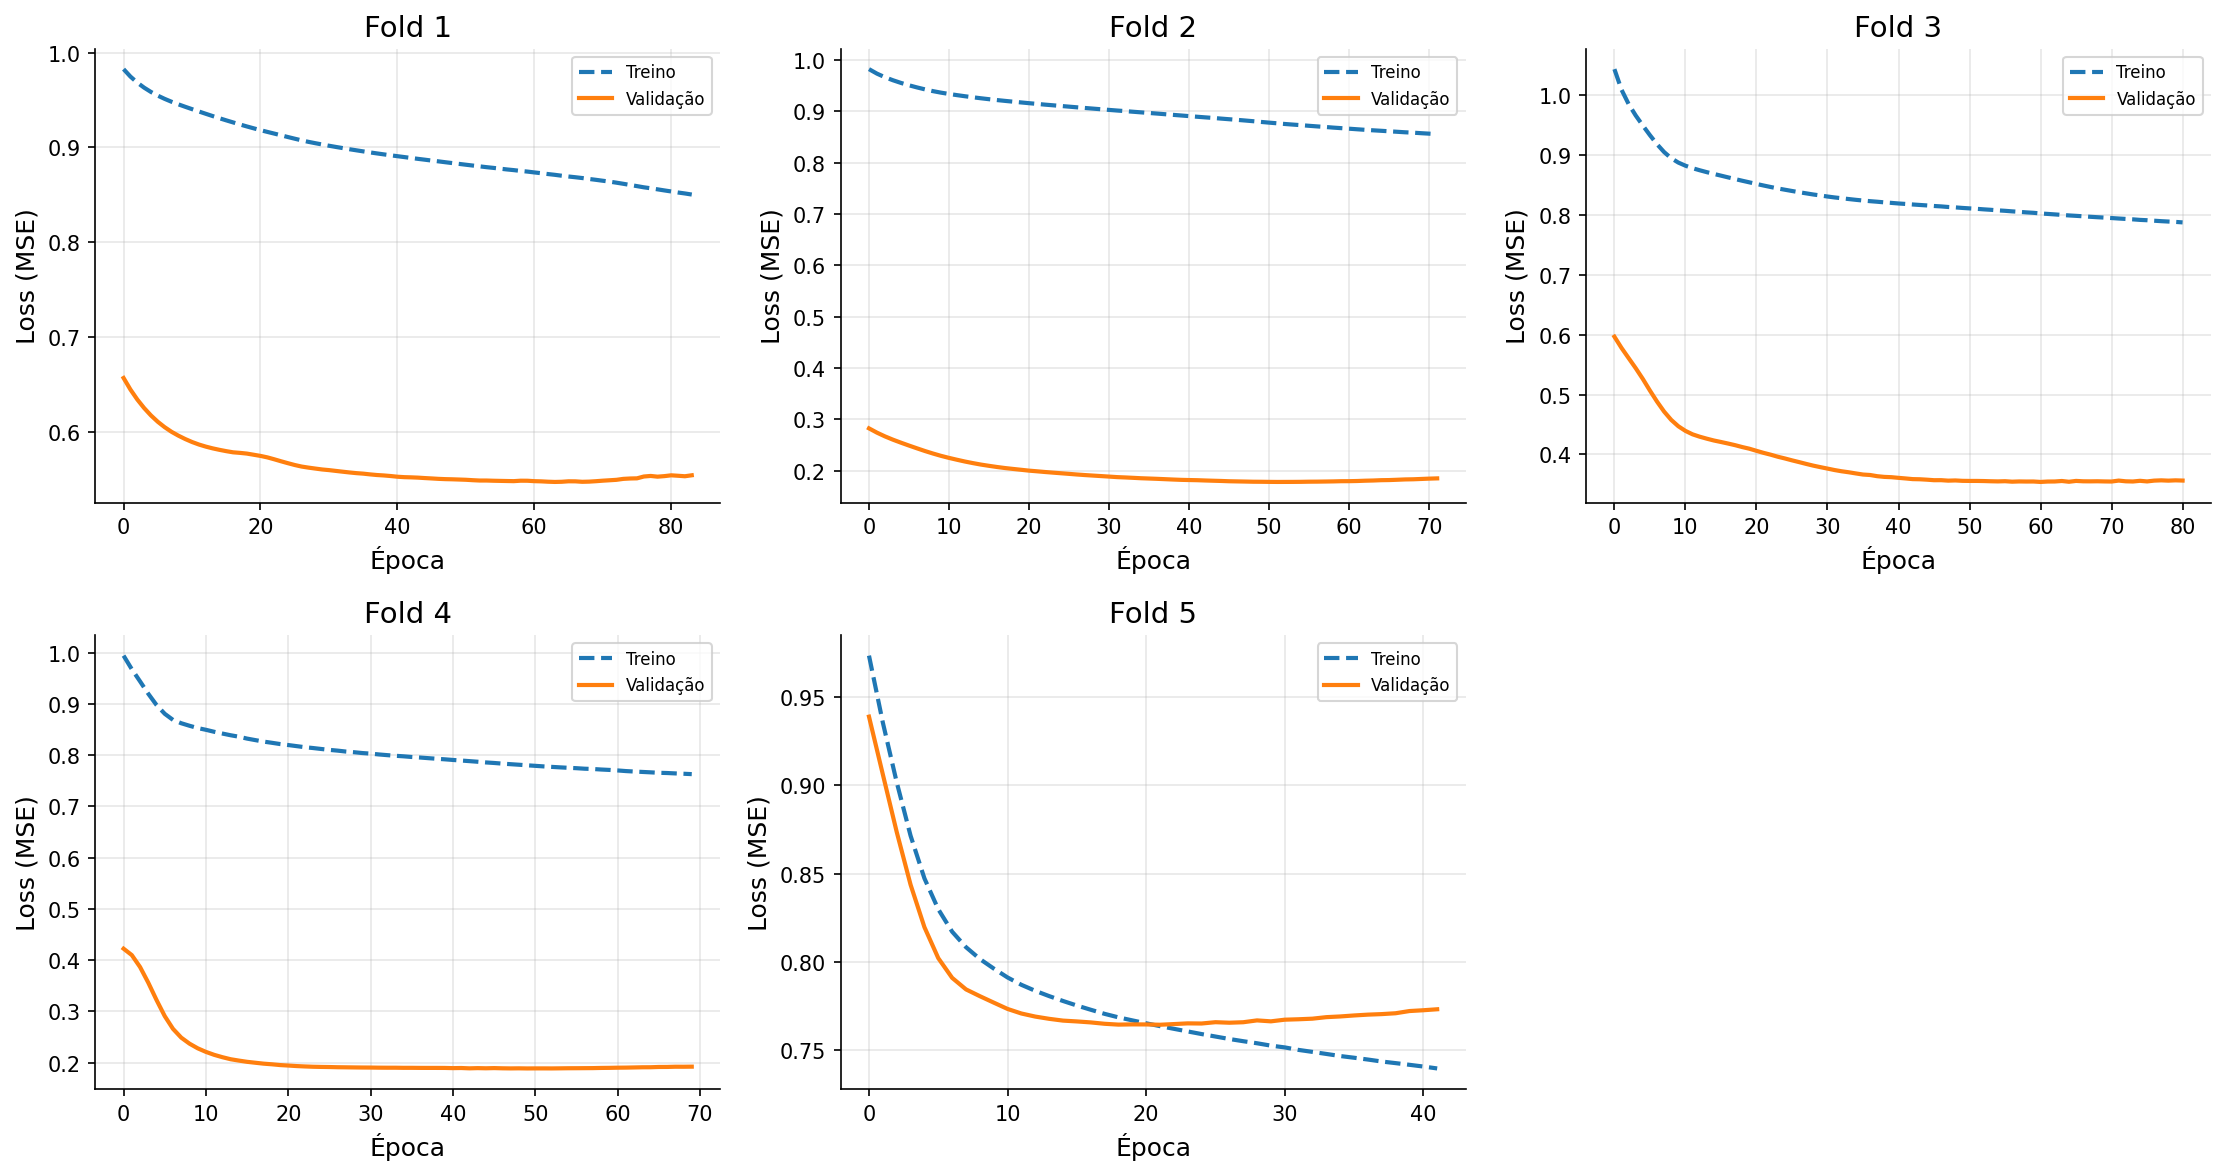

In [ ]:
# Subplots das curvas por fold
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Transformar matriz 2x3 em vetor
axes = axes.flatten()

for i, hist in enumerate(historicos_folds):

    fold = hist["fold"]

    train_loss = hist["train_loss"]
    val_loss = hist["val_loss"]

    ax = axes[i]

    # Curva de treino
    ax.plot(
        train_loss,
        linestyle="--",
        linewidth=2,
        label="Treino"
    )

    # Curva de validação
    ax.plot(
        val_loss,
        linewidth=2,
        label="Validação"
    )

    ax.set_title(f"Fold {fold}")

    ax.set_xlabel("Época")
    ax.set_ylabel("Loss (MSE)")

    ax.grid(True, alpha=0.3)

    ax.legend(fontsize=8)

# Remove o sexto subplot vazio
fig.delaxes(axes[-1])

plt.tight_layout()

plt.savefig(
    "folds_subplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Treinamento do modelo final

Depois de escolher os melhores hiperparâmetros, vamos treinar um modelo final.

Para manter o Early Stopping, vamos separar os últimos 20% dos dados observados como validação temporal.

In [ ]:
# Separação temporal: 80% treino, 20% validação
ponto_corte = int(len(X) * 0.8)

X_train_final = X[:ponto_corte]
X_val_final = X[ponto_corte:]

y_train_final = y[:ponto_corte]
y_val_final = y[ponto_corte:]

# Normalização final
scaler_X_final = StandardScaler()
scaler_y_final = StandardScaler()

X_train_final_scaled = scaler_X_final.fit_transform(X_train_final)
X_val_final_scaled = scaler_X_final.transform(X_val_final)

y_train_final_scaled = scaler_y_final.fit_transform(y_train_final)
y_val_final_scaled = scaler_y_final.transform(y_val_final)

train_loader_final = criar_loader(
    X_train_final_scaled,
    y_train_final_scaled,
    batch_size=best_params["batch_size"],
    shuffle=False
)

val_loader_final = criar_loader(
    X_val_final_scaled,
    y_val_final_scaled,
    batch_size=best_params["batch_size"],
    shuffle=False
)

modelo_final = MLPImputador(
    input_dim=X.shape[1],
    hidden_dim=best_params["hidden_dim"],
    num_layers=best_params["num_layers"]
).to(device)

optimizer_final = torch.optim.Adam(
    modelo_final.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

criterion = nn.MSELoss()

modelo_final, train_losses_final, val_losses_final, melhor_val_loss_final = treinar_modelo(
    model=modelo_final,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    optimizer=optimizer_final,
    criterion=criterion,
    max_epochs=300,
    patience=30
)

print("Melhor loss de validação final:", melhor_val_loss_final)

Melhor loss de validação final: 0.6923670999028466


# Curva de loss do modelo final

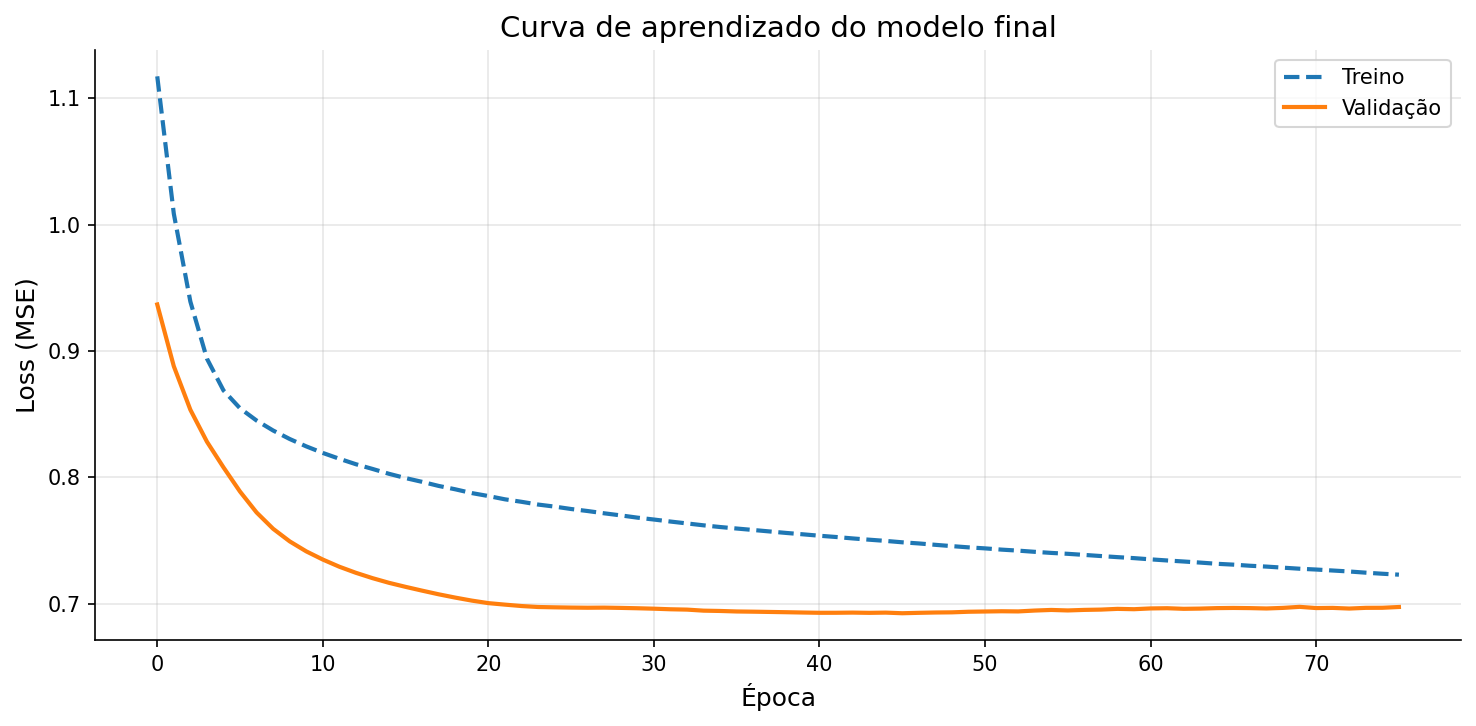

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses_final,
    linestyle="--",
    linewidth=2,
    label="Treino"
)

plt.plot(
    val_losses_final,
    linewidth=2,
    label="Validação"
)

plt.title("Curva de aprendizado do modelo final")

plt.xlabel("Época")
plt.ylabel("Loss (MSE)")

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "modelo_final_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Imputação dos valores removidos

Agora vamos usar o modelo final para prever os valores que foram removidos artificialmente.

In [ ]:
# Separar os dados que precisam ser imputados
df_missing = df_experimento.loc[indices_removidos].copy()

X_missing = df_missing[features].values

# Aplicar o mesmo scaler usado no modelo final
X_missing_scaled = scaler_X_final.transform(X_missing)

X_missing_tensor = torch.tensor(
    X_missing_scaled,
    dtype=torch.float32
).to(device)

modelo_final.eval()

with torch.no_grad():
    pred_scaled = modelo_final(X_missing_tensor).cpu().numpy()

# Voltar para a escala original
valores_imputados = scaler_y_final.inverse_transform(pred_scaled).flatten()

# Criar coluna de imputação
df_experimento["nu_concentracao_imputada"] = df_experimento["nu_concentracao_com_missing"]

# Inserir valores imputados nos índices removidos
df_experimento.loc[indices_removidos, "nu_concentracao_imputada"] = valores_imputados

df_experimento.head()

,nu_concentracao,mes,dia,hora,dia_semana,lag_1,lag_2,lag_3,lag_24,lag_48,media_3,media_6,media_12,nu_concentracao_com_missing,nu_concentracao_imputada
0,14.0,1,11,2,5,6.0,9.0,14.0,15.0,38.0,9.666667,16.500000,15.083333,14.0,14.0
1,16.0,1,11,3,5,14.0,6.0,9.0,13.0,34.0,9.666667,15.333333,15.166667,16.0,16.0
2,12.0,1,11,4,5,16.0,14.0,6.0,13.0,35.0,12.000000,13.166667,15.083333,12.0,12.0
3,6.0,1,11,5,5,12.0,16.0,14.0,8.0,25.0,14.000000,11.833333,15.250000,6.0,6.0
4,4.0,1,11,6,5,6.0,12.0,16.0,7.0,21.0,11.333333,10.500000,14.666667,4.0,4.0


# Série temporal: valores reais, removidos e imputados



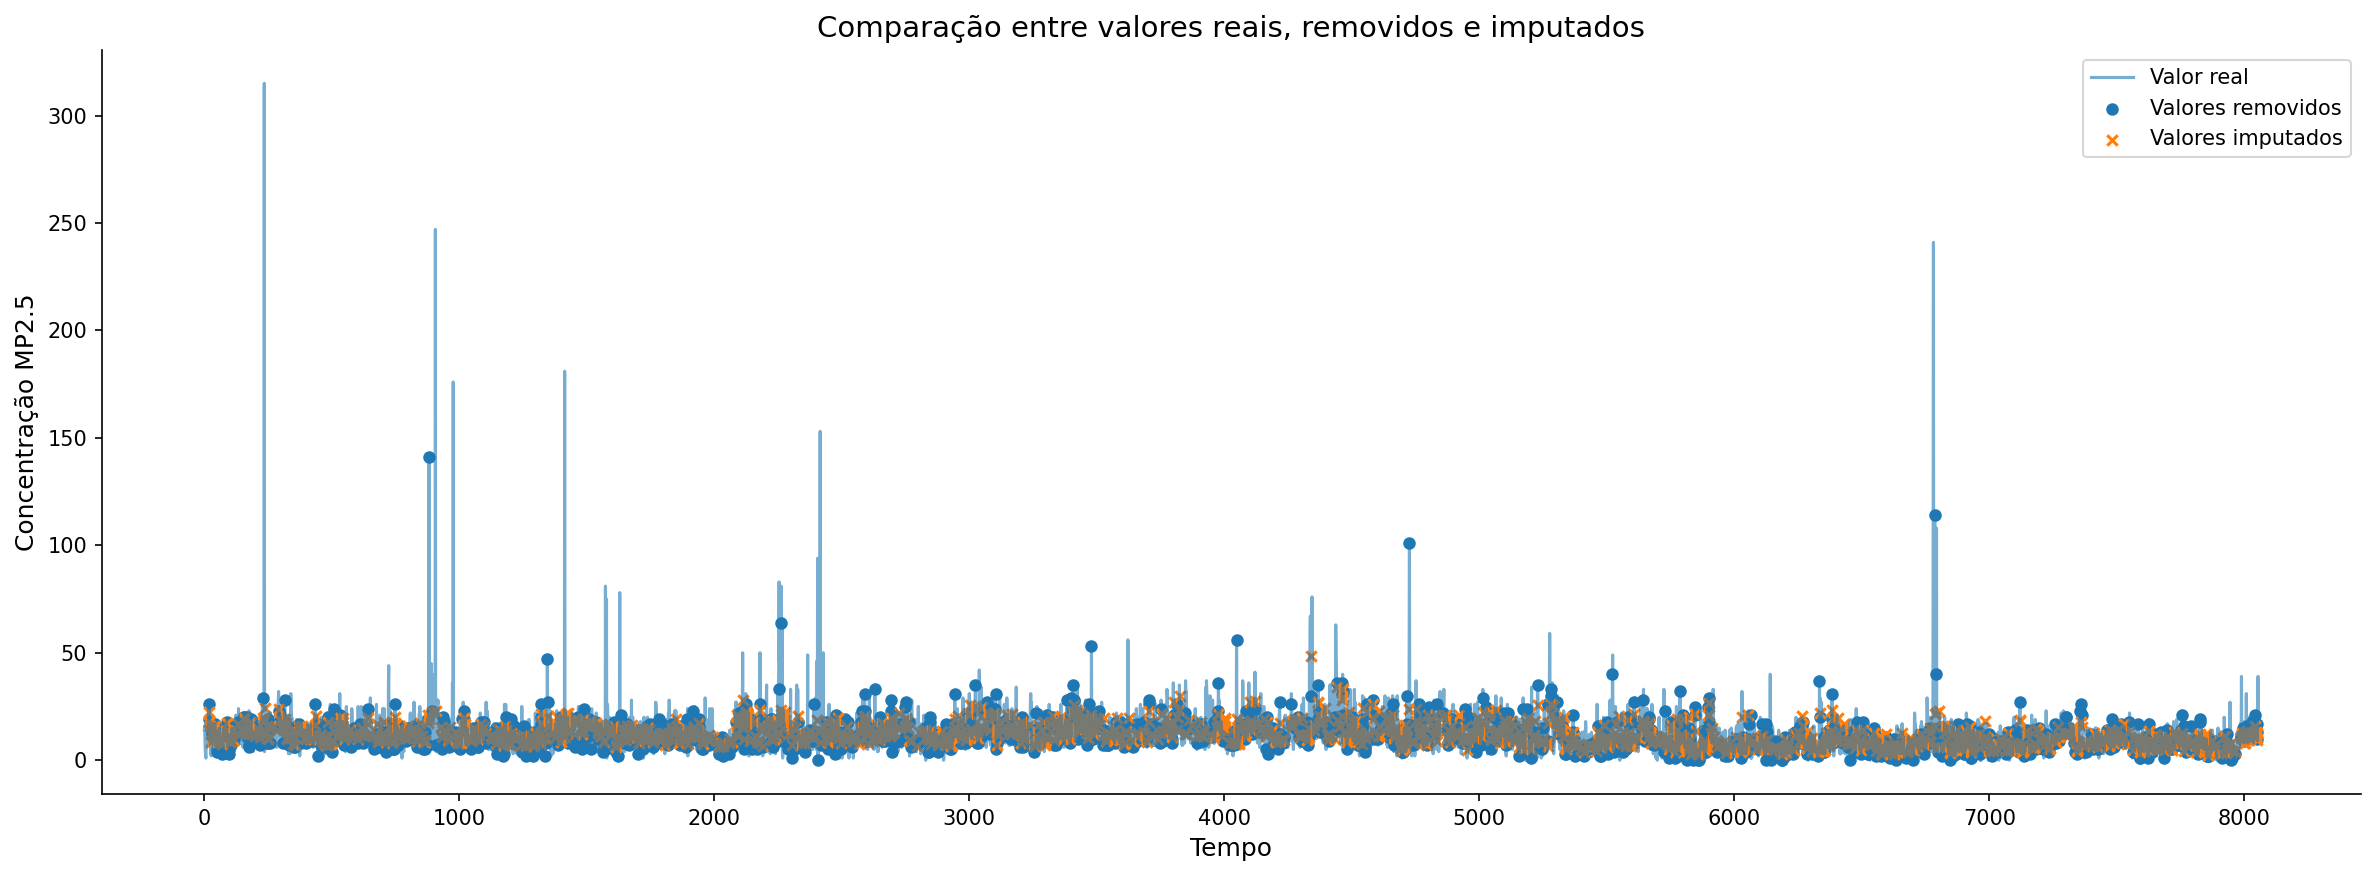

In [ ]:
plt.figure(figsize=(16,6))

# Série original
plt.plot(
    eixo_tempo,
    df_experimento[target],
    label="Valor real",
    alpha=0.6
)

# Valores removidos
plt.scatter(
    np.array(eixo_tempo)[indices_removidos],
    valores_reais_removidos,
    label="Valores removidos",
    s=25
)

# Valores imputados
plt.scatter(
    np.array(eixo_tempo)[indices_removidos],
    valores_imputados,
    label="Valores imputados",
    s=25,
    marker="x"
)

plt.title("Comparação entre valores reais, removidos e imputados")
plt.xlabel("Tempo")
plt.ylabel("Concentração MP2.5")
plt.legend()

plt.tight_layout()
plt.show()

# Zoom nos valores removidos e imputados

Como a série completa pode ficar muito carregada, vamos visualizar apenas uma janela menor.

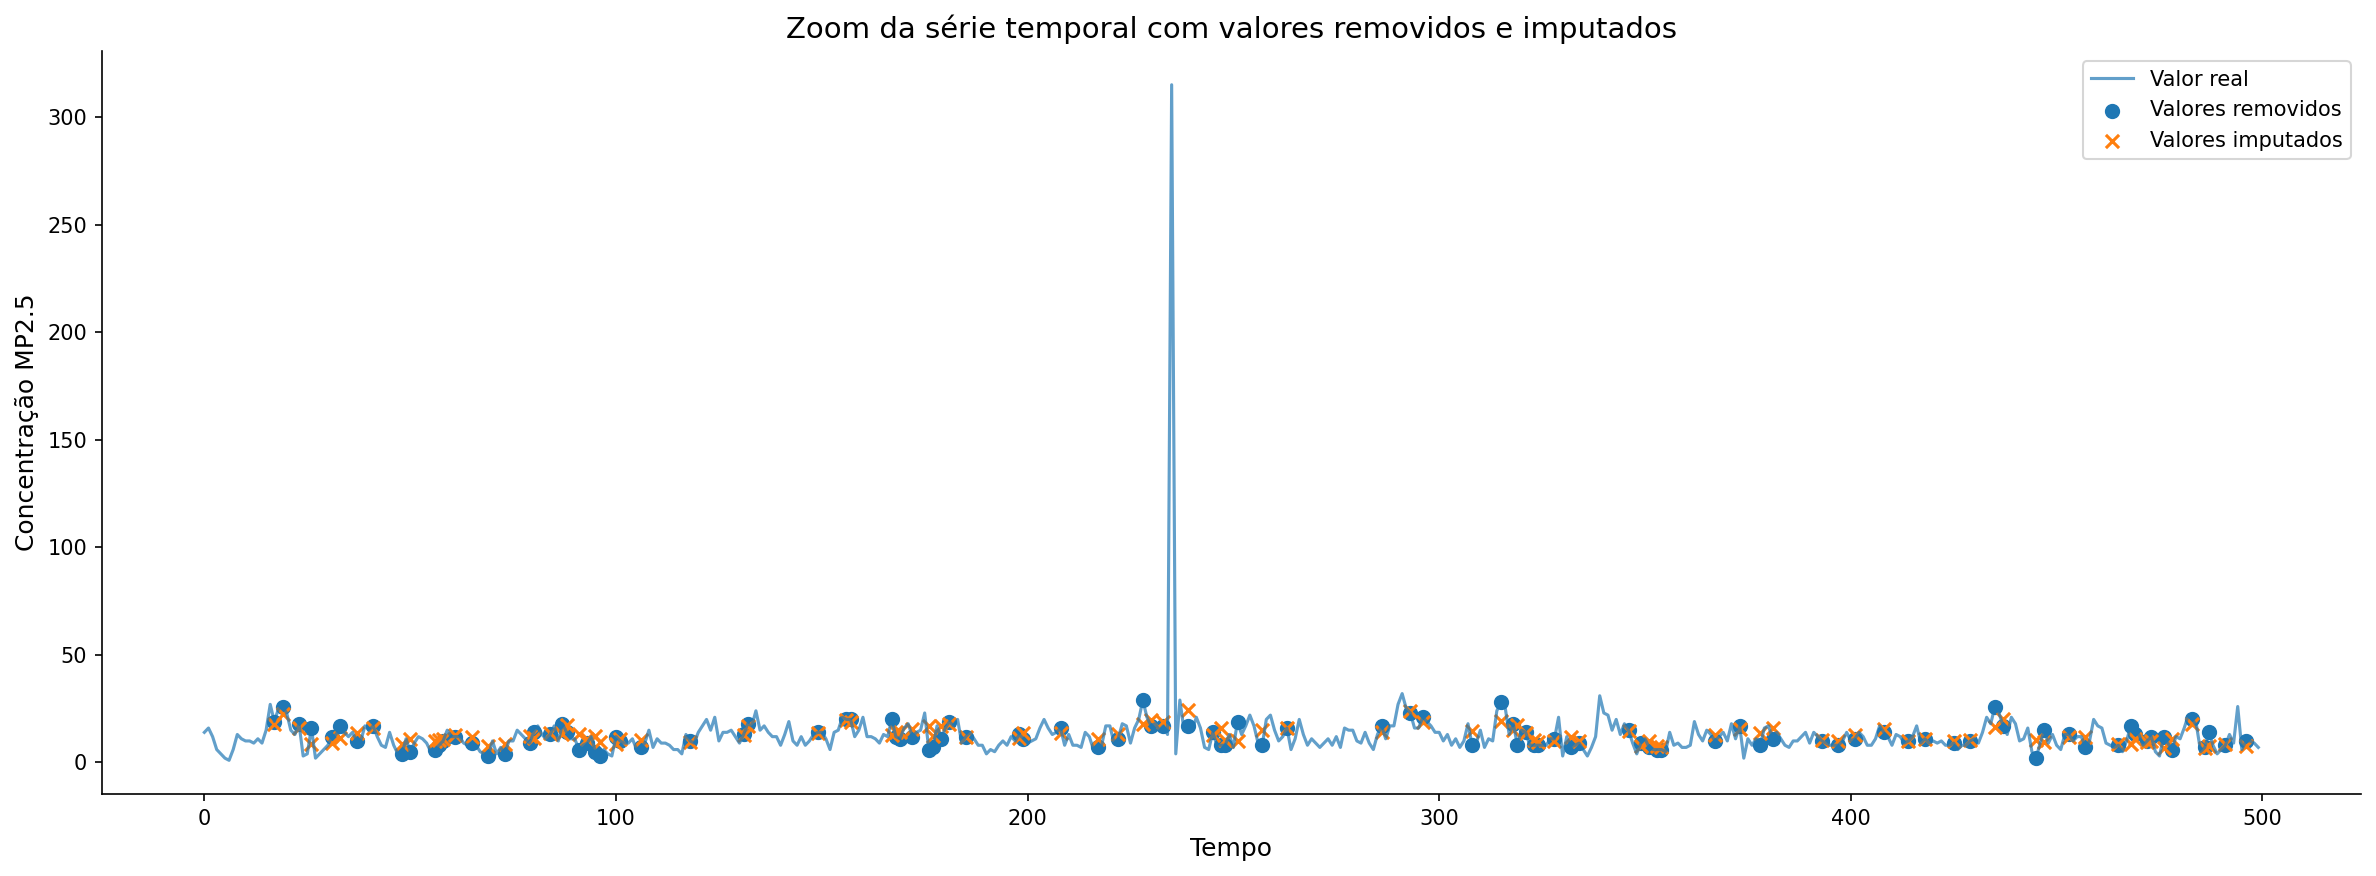

In [ ]:
# Escolher uma janela temporal para visualização
inicio = 0
fim = 500

indices_janela = np.arange(inicio, fim)

indices_removidos_janela = [
    idx for idx in indices_removidos
    if inicio <= idx < fim
]

plt.figure(figsize=(16,6))

plt.plot(
    np.array(eixo_tempo)[indices_janela],
    df_experimento[target].iloc[inicio:fim],
    label="Valor real",
    alpha=0.7
)

plt.scatter(
    np.array(eixo_tempo)[indices_removidos_janela],
    df_experimento.loc[indices_removidos_janela, target],
    label="Valores removidos",
    s=40
)

plt.scatter(
    np.array(eixo_tempo)[indices_removidos_janela],
    df_experimento.loc[indices_removidos_janela, "nu_concentracao_imputada"],
    label="Valores imputados",
    s=40,
    marker="x"
)

plt.title("Zoom da série temporal com valores removidos e imputados")
plt.xlabel("Tempo")
plt.ylabel("Concentração MP2.5")
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_581/3584379256.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


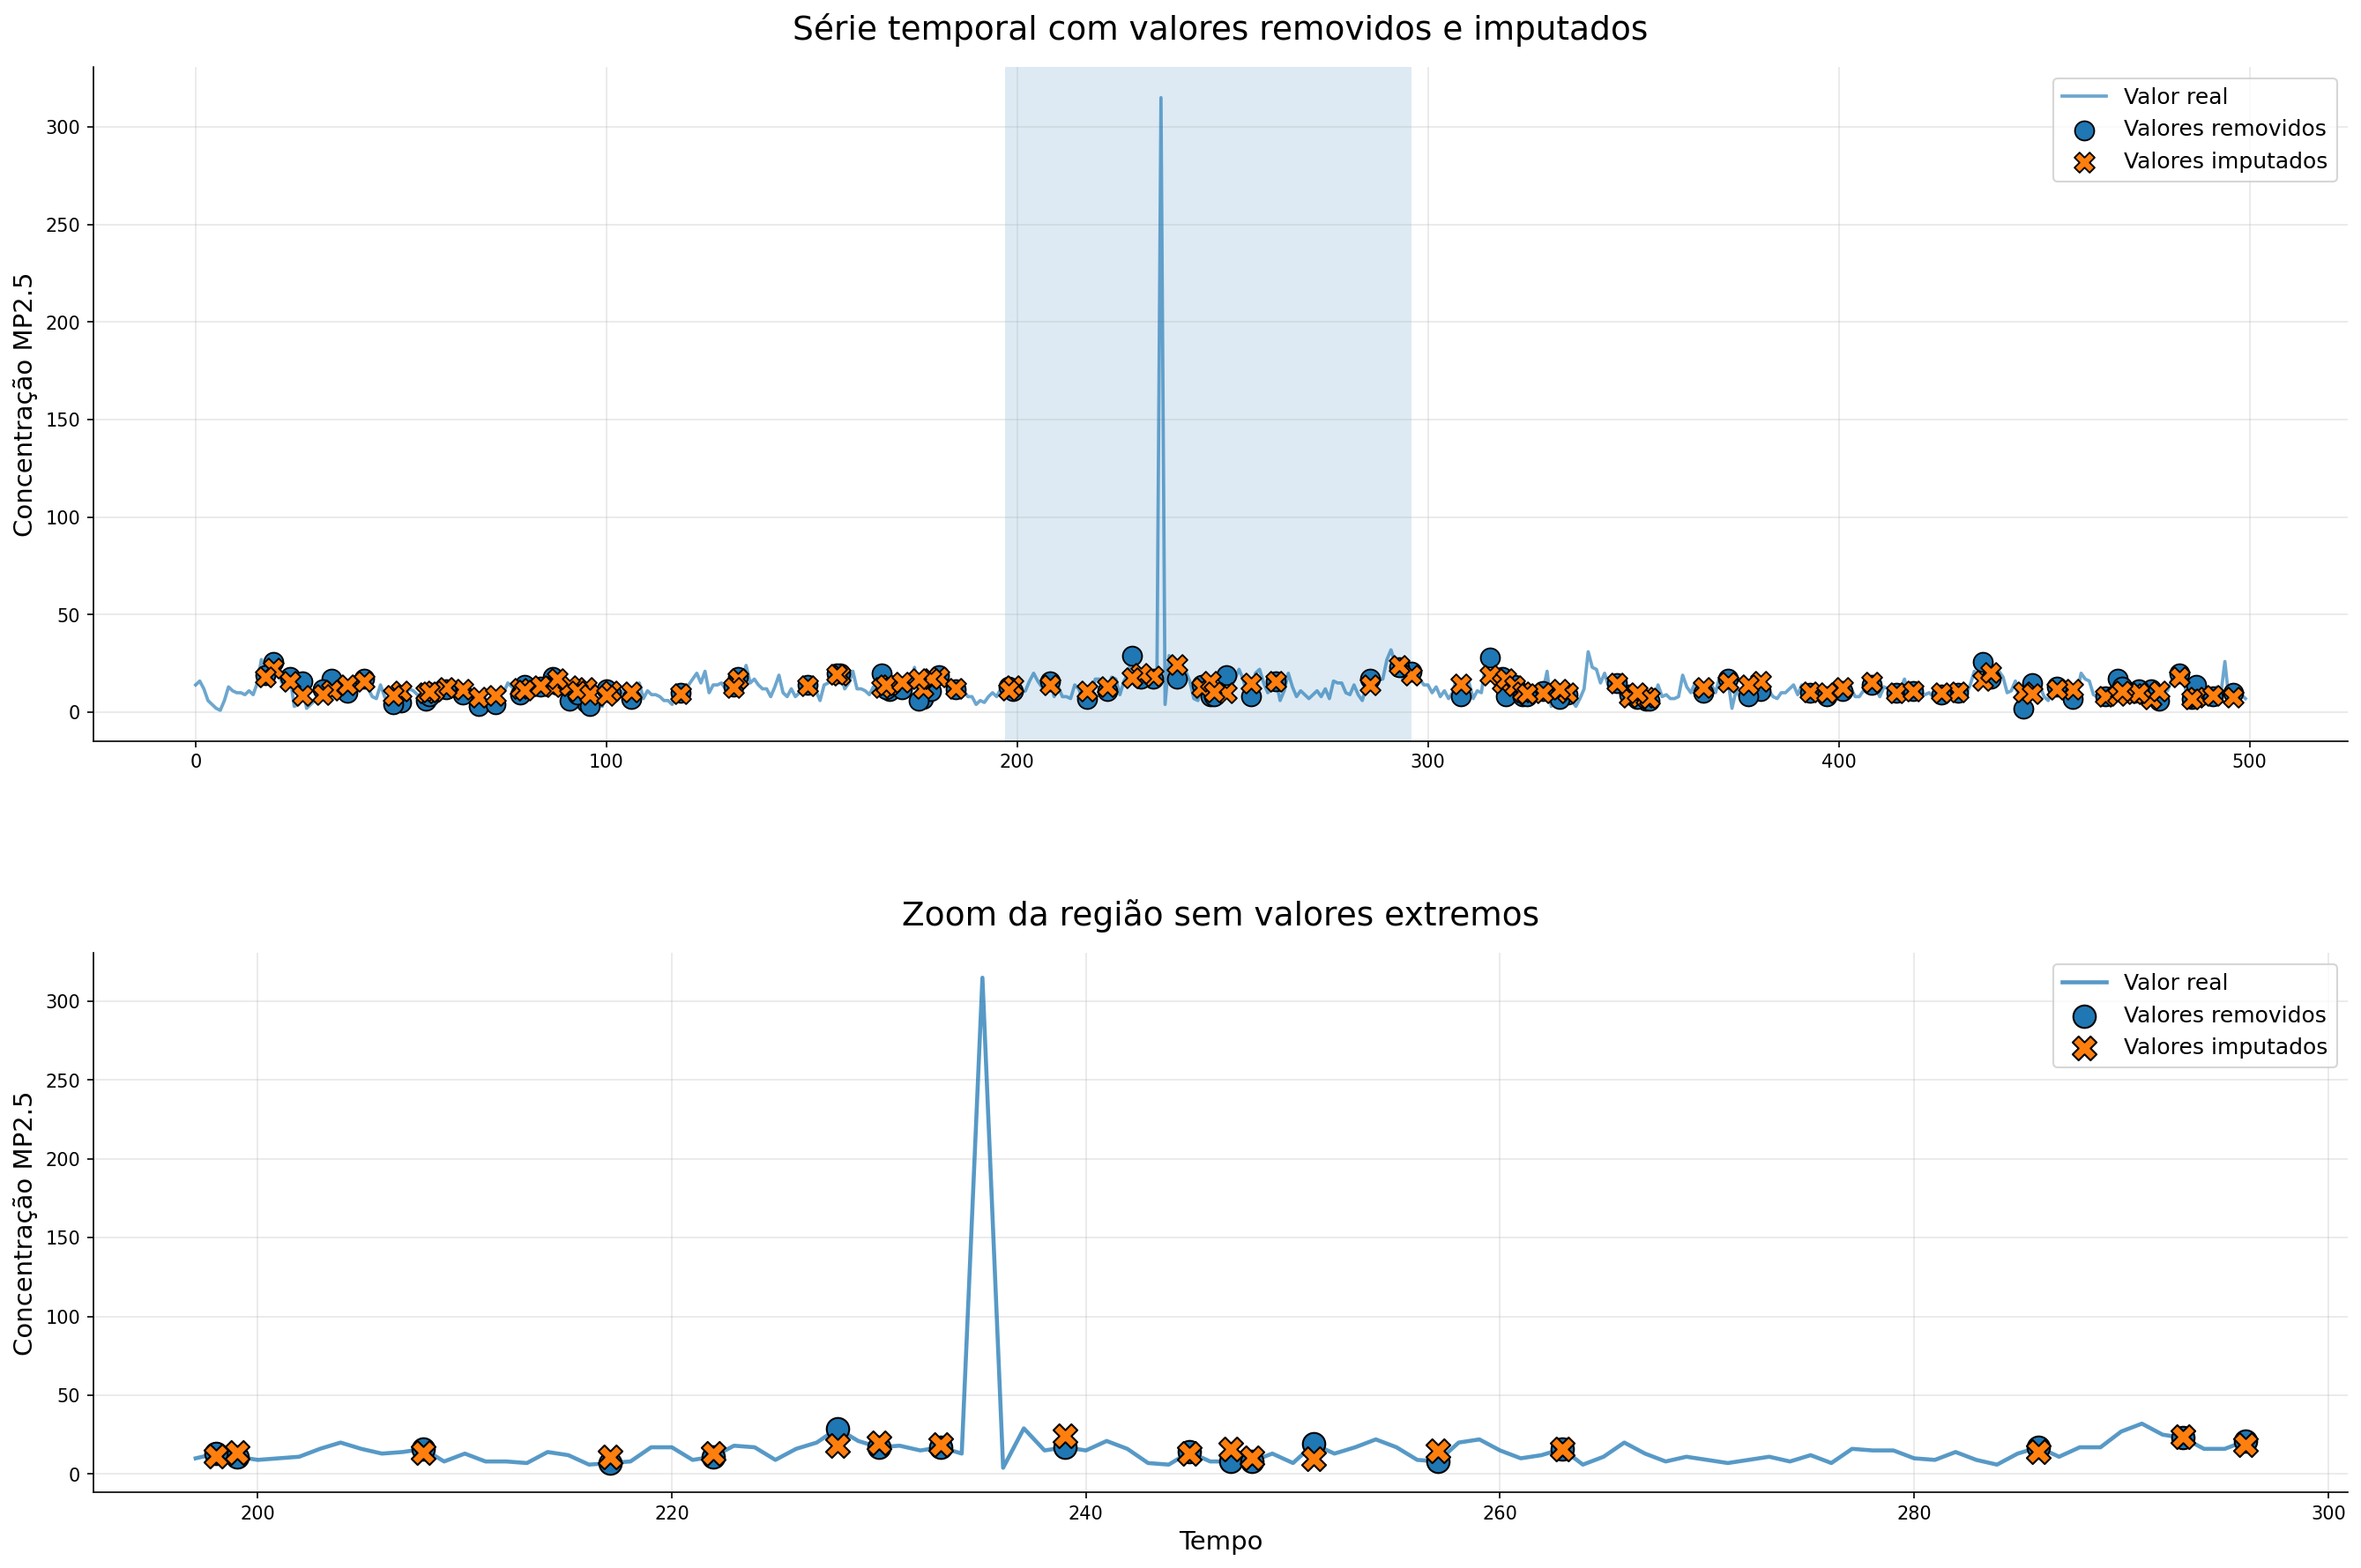

In [ ]:
# Escolher uma janela temporal para visualização geral
inicio = 0
fim = 500

indices_janela = np.arange(inicio, fim)

indices_removidos_janela = [
    idx for idx in indices_removidos
    if inicio <= idx < fim
]

tempo_janela = np.array(eixo_tempo)[indices_janela]

# ==========================
# Definir automaticamente uma janela de zoom sem extremos
# ==========================

# Valores reais dentro da janela principal
serie_janela = df_experimento[target].iloc[inicio:fim]

# Limites por percentis apenas para achar uma região visualmente boa
limite_inferior = serie_janela.quantile(0.05)
limite_superior = serie_janela.quantile(0.95)

# Procurar índices dentro da janela sem extremos
indices_sem_extremos = [
    idx for idx in indices_janela
    if (
        df_experimento.loc[idx, target] >= limite_inferior
        and df_experimento.loc[idx, target] <= limite_superior
    )
]

# Definir uma janela menor de zoom
# Aqui pegamos uma região central sem extremos
centro_zoom = indices_sem_extremos[len(indices_sem_extremos) // 2]

largura_zoom = 100

inicio_zoom = max(inicio, centro_zoom - largura_zoom // 2)
fim_zoom = min(fim, centro_zoom + largura_zoom // 2)

indices_zoom = np.arange(inicio_zoom, fim_zoom)

indices_removidos_zoom = [
    idx for idx in indices_removidos
    if inicio_zoom <= idx < fim_zoom
]

tempo_zoom = np.array(eixo_tempo)[indices_zoom]

# ==========================
# Figura
# ==========================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(22, 14),
    sharex=False,
    gridspec_kw={"height_ratios": [2, 1.6], "hspace": 0.35}
)

# ==========================
# Plot 1 — série temporal completa da janela
# ==========================

axes[0].plot(
    tempo_janela,
    df_experimento[target].iloc[inicio:fim],
    linewidth=1.8,
    alpha=0.65,
    label="Valor real"
)

axes[0].scatter(
    np.array(eixo_tempo)[indices_removidos_janela],
    df_experimento.loc[indices_removidos_janela, target],
    s=110,
    marker="o",
    edgecolors="black",
    linewidth=0.9,
    zorder=5,
    label="Valores removidos"
)

axes[0].scatter(
    np.array(eixo_tempo)[indices_removidos_janela],
    df_experimento.loc[
        indices_removidos_janela,
        "nu_concentracao_imputada"
    ],
    s=120,
    marker="X",
    edgecolors="black",
    linewidth=0.9,
    zorder=6,
    label="Valores imputados"
)

axes[0].set_title(
    "Série temporal com valores removidos e imputados",
    fontsize=18,
    pad=15
)

axes[0].set_ylabel("Concentração MP2.5", fontsize=14)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=12)

# Marcar no gráfico de cima a região ampliada
axes[0].axvspan(
    np.array(eixo_tempo)[inicio_zoom],
    np.array(eixo_tempo)[fim_zoom - 1],
    alpha=0.15,
    label="Região ampliada"
)

# ==========================
# Plot 2 — zoom da própria série, sem extremos
# ==========================

axes[1].plot(
    tempo_zoom,
    df_experimento[target].iloc[inicio_zoom:fim_zoom],
    linewidth=2.2,
    alpha=0.75,
    label="Valor real"
)

axes[1].scatter(
    np.array(eixo_tempo)[indices_removidos_zoom],
    df_experimento.loc[indices_removidos_zoom, target],
    s=150,
    marker="o",
    edgecolors="black",
    linewidth=1,
    zorder=5,
    label="Valores removidos"
)

axes[1].scatter(
    np.array(eixo_tempo)[indices_removidos_zoom],
    df_experimento.loc[
        indices_removidos_zoom,
        "nu_concentracao_imputada"
    ],
    s=170,
    marker="X",
    edgecolors="black",
    linewidth=1,
    zorder=6,
    label="Valores imputados"
)

axes[1].set_title(
    "Zoom da região sem valores extremos",
    fontsize=18,
    pad=15
)

axes[1].set_xlabel("Tempo", fontsize=14)
axes[1].set_ylabel("Concentração MP2.5", fontsize=14)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "comparacao_imputacao_zoom_profissional.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Cálculo dos erros de imputação

Agora vamos comparar apenas os valores que foram removidos artificialmente.

O erro será calculado como:

`erro = valor_real - valor_imputado`

In [ ]:
# Criar dataframe de comparação
df_comparacao = pd.DataFrame({
    "indice": indices_removidos,
    "valor_real": valores_reais_removidos.values,
    "valor_imputado": valores_imputados
})

# Calcular erro
df_comparacao["erro"] = (
    df_comparacao["valor_real"] -
    df_comparacao["valor_imputado"]
)

# Erro absoluto
df_comparacao["erro_absoluto"] = df_comparacao["erro"].abs()

df_comparacao.head()

,indice,valor_real,valor_imputado,erro,erro_absoluto
0,2748,25.0,15.778498,9.221502,9.221502
1,6273,9.0,10.112535,-1.112535,1.112535
2,2034,2.0,6.777308,-4.777308,4.777308
3,5927,5.0,8.754314,-3.754314,3.754314
4,3340,7.0,15.311641,-8.311641,8.311641


# Métricas de avaliação

In [ ]:
mae = mean_absolute_error(
    df_comparacao["valor_real"],
    df_comparacao["valor_imputado"]
)

rmse = np.sqrt(
    mean_squared_error(
        df_comparacao["valor_real"],
        df_comparacao["valor_imputado"]
    )
)

r2 = r2_score(
    df_comparacao["valor_real"],
    df_comparacao["valor_imputado"]
)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  3.8893
RMSE: 6.7086
R²:   0.3243


# Distribuição do erro

Aqui visualizamos a distribuição do erro:

`valor_real - valor_imputado`

Valores próximos de zero indicam melhor imputação.

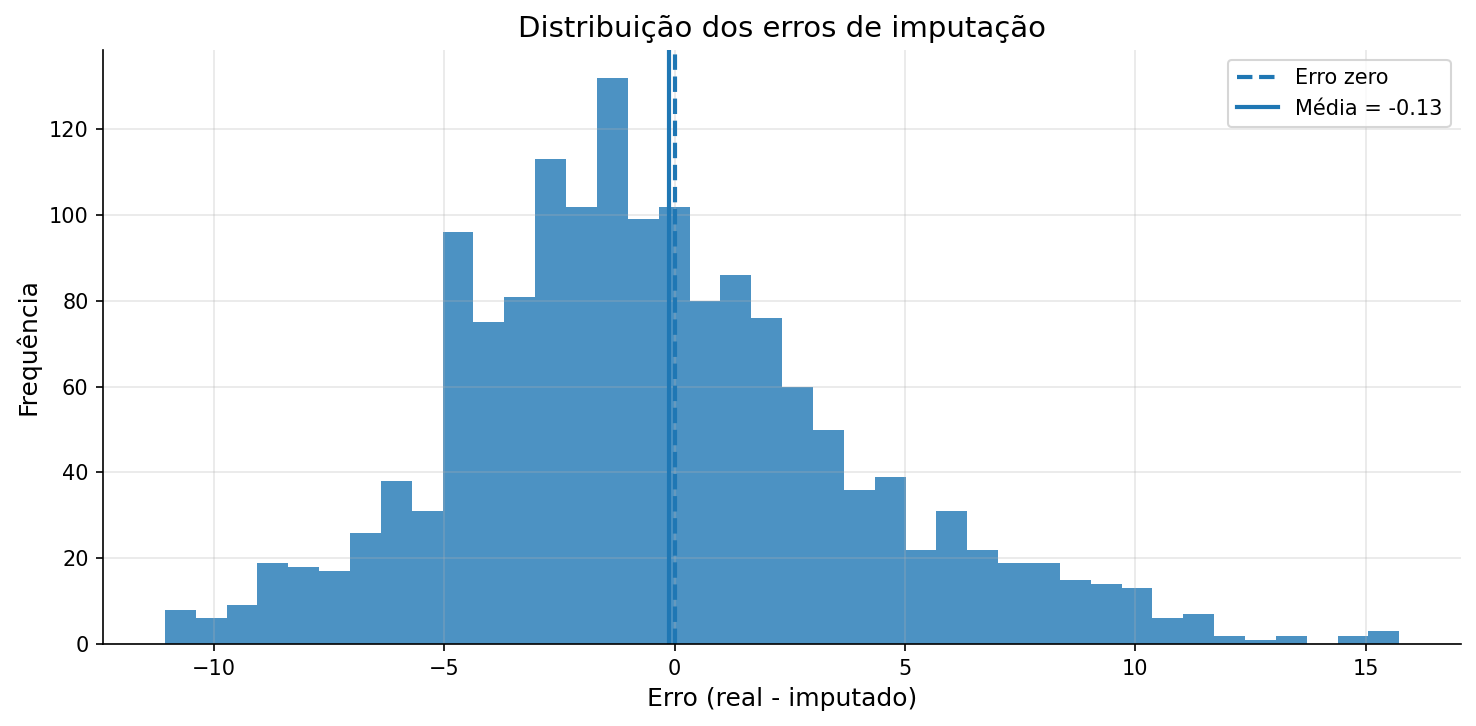

In [ ]:
erro = df_comparacao["erro"]

media = erro.mean()
desvio = erro.std()

p1 = erro.quantile(0.01)
p99 = erro.quantile(0.99)

erro_filtrado = erro[
    (erro >= p1) &
    (erro <= p99)
]

plt.figure(figsize=(10,5))

plt.hist(
    erro_filtrado,
    bins=40,
    alpha=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Erro zero"
)

plt.axvline(
    media,
    linestyle="-",
    linewidth=2,
    label=f"Média = {media:.2f}"
)

plt.title("Distribuição dos erros de imputação")

plt.xlabel("Erro (real - imputado)")
plt.ylabel("Frequência")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

# Erro ao longo da série temporal

Agora vamos observar se o erro acontece de forma aleatória ou se existem regiões da série em que o modelo erra mais.

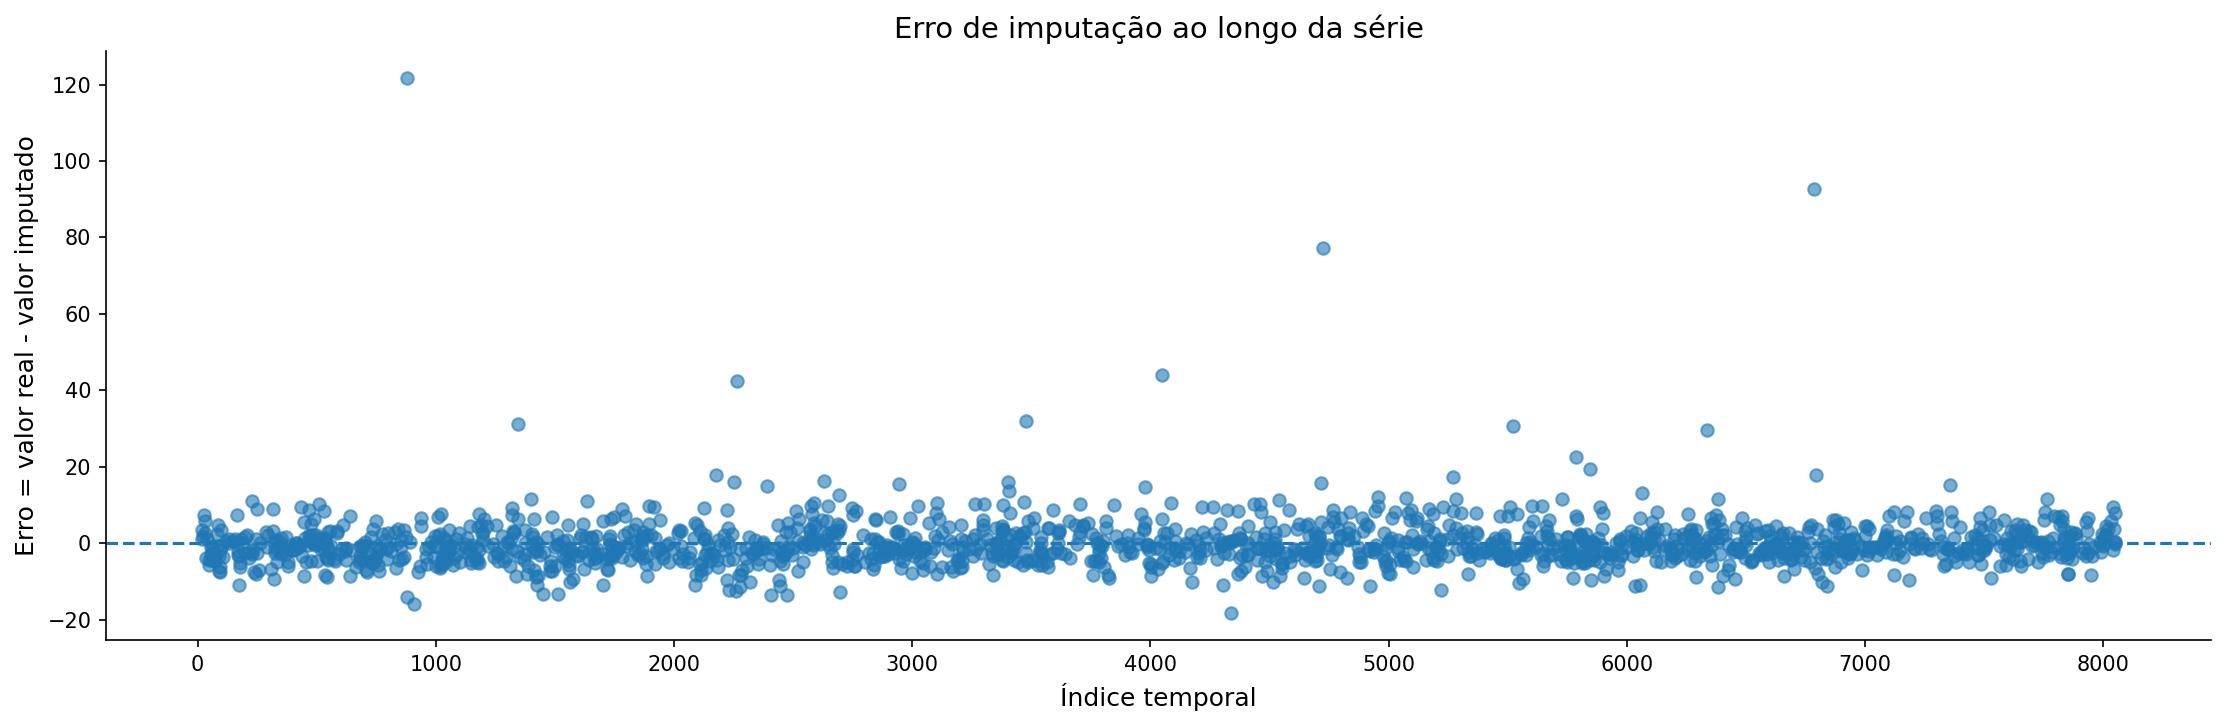

In [ ]:
df_comparacao = df_comparacao.sort_values("indice")

plt.figure(figsize=(15,5))

plt.plot(
    df_comparacao["indice"],
    df_comparacao["erro"],
    marker="o",
    linestyle="none",
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.title("Erro de imputação ao longo da série")
plt.xlabel("Índice temporal")
plt.ylabel("Erro = valor real - valor imputado")

plt.tight_layout()
plt.show()

# Comparação real vs imputado

Este gráfico mostra se os valores imputados estão próximos dos valores reais.

Quanto mais próximos da reta diagonal, melhor.

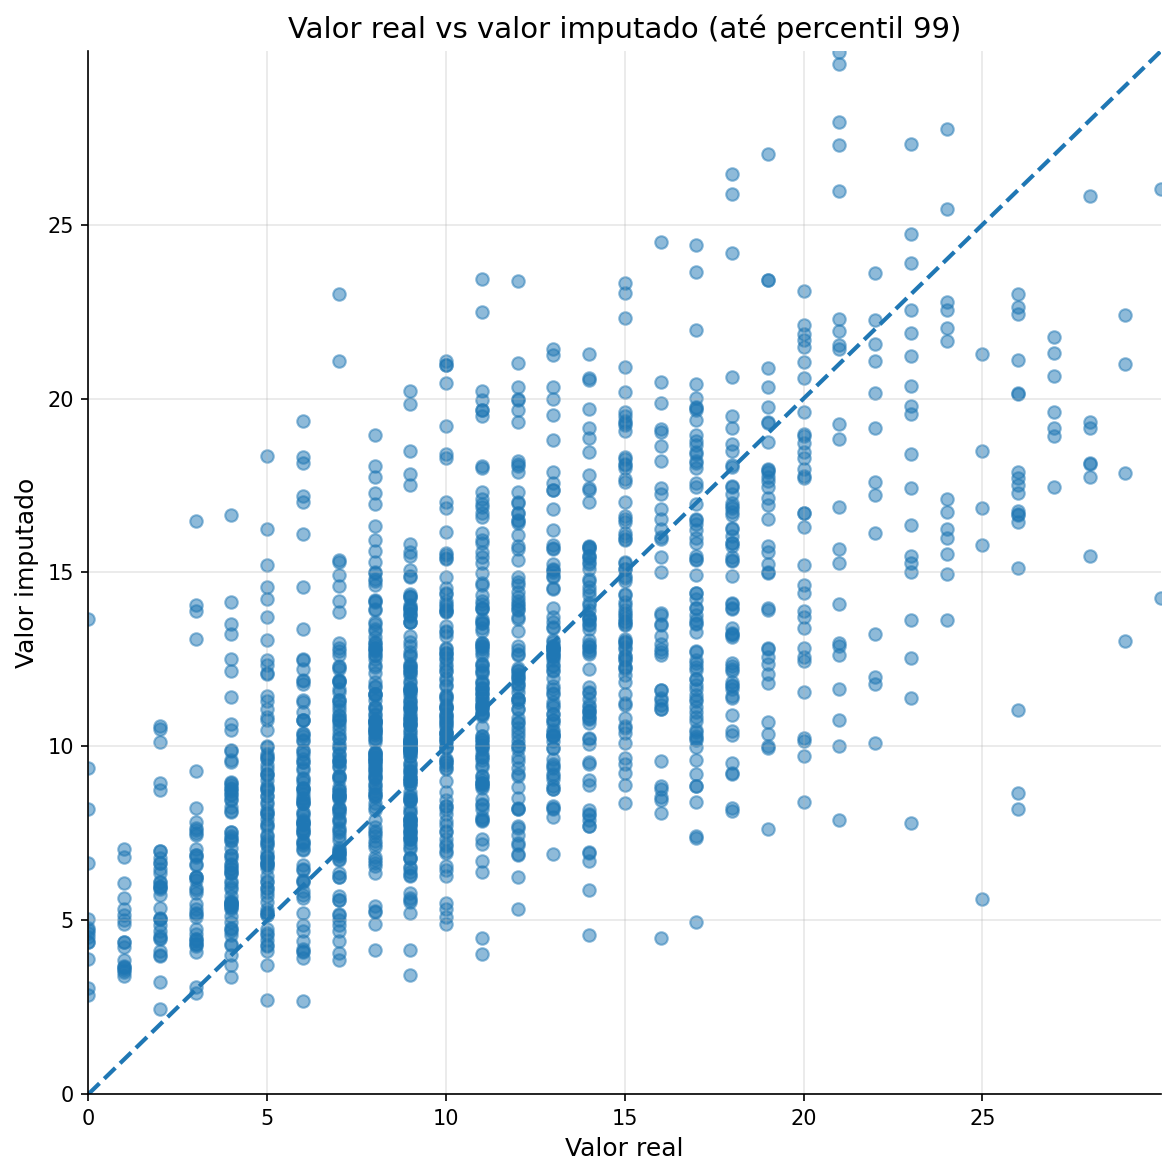

In [ ]:
limite = np.percentile(
    np.concatenate([
        df_comparacao["valor_real"],
        df_comparacao["valor_imputado"]
    ]),
    99
)

plt.figure(figsize=(8,8))

plt.scatter(
    df_comparacao["valor_real"],
    df_comparacao["valor_imputado"],
    alpha=0.5
)

plt.plot(
    [0, limite],
    [0, limite],
    linestyle="--",
    linewidth=2
)

plt.xlim(0, limite)
plt.ylim(0, limite)

plt.title("Valor real vs valor imputado (até percentil 99)")
plt.xlabel("Valor real")
plt.ylabel("Valor imputado")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Salvando resultados da imputação


In [ ]:
df_experimento.to_csv(
    "dataset_mp25_com_imputacao_mlp.csv",
    index=False
)

df_comparacao.to_csv(
    "comparacao_valores_reais_imputados.csv",
    index=False
)

print("Arquivos salvos com sucesso.")

Arquivos salvos com sucesso.


## Experimento 2 - Imputação com autoencoder